Check the initial vertical velocity for MPAS is fine.
Then, compare simulations with and without the initial vertical velocity

In [1]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [58]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [20]:
rot = False

dycore = 'CAM-MPAS'
res = 'mpasa60'
test_name_start = 'cam_6_4_080'

lev_no_zero = 'L20km_L57'
lev_no_nonzero = 'L20km_L57_nonzero_w2'
extra_name = '_nonzero_w0'

case_zero = f'{test_name_start}_paper_six_{res}_{lev_no_zero}'
case_nonzero = f'{test_name_start}_paper_six_{res}_{lev_no_nonzero}'

if rot:
    nc_file_zero = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot.regrid.0.5x0.5.nc'
    nc_file_nonzero = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot{extra_name}.regrid.0.5x0.5.nc'
else:
    nc_file_zero = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0.regrid.0.5x0.5.nc'
    nc_file_nonzero = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0{extra_name}.regrid.0.5x0.5.nc'

In [22]:
run_base = "/glade/derecho/scratch/timand/"

run_path_zero = run_base + case + '/run/' + nc_file_zero
run_path_nonzero = run_base + case + '/run/' + nc_file_nonzero

nc_zero = Dataset(run_path_zero)
nc_nonzero = Dataset(run_path_nonzero)

time = nc_zero['time'][:]
lev = nc_zero['lev'][:]
lat = nc_zero['lat'][:] 
lon = nc_zero['lon'][:] 
print(lev[-1])

LON, LAT = np.meshgrid(lon,lat)

50.00000111758712


In [55]:
# Initial omega

lev_index = -1

omega_zero = nc_zero['OMEGA'][0, lev_index,:,:]
omega_nonzero = nc_nonzero['OMEGA'][0, lev_index,:,:]
#print(np.shape(omega))
#omega_field = omega[0, lev_index,:,:]
#T_field = nc['T'][0, lev_index, :,:]
#P = lev[lev_index]
#P_Pa = P*100

# Convert OMEGA to w:
Rd = 287.04
g = 9.80616
T0 = 288
P_Pa = lev[lev_index]*100

print(Rd*T0/g/P_Pa)

w_zero = -(Rd/g)*omega_zero*T0/P_Pa
w_nonzero = -(Rd/g)*omega_nonzero*T0/P_Pa

1.686032415384553


Maximum omega is 25.651432037353516 Pa/s
Minimum omega is -25.933996200561523 Pa/s


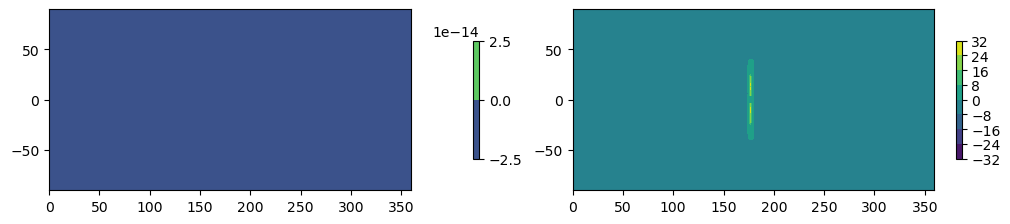

In [56]:
# Plot! OMEGA first
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,6), constrained_layout=True)
plot1 = ax1.contourf(LON, LAT, omega_zero)
plot2 = ax2.contourf(LON, LAT, omega_nonzero)

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.colorbar(plot1,shrink=0.2)
plt.colorbar(plot2,shrink=0.2)

print(f'Maximum omega is {np.max(omega_nonzero)} Pa/s')
print(f'Minimum omega is {np.min(omega_nonzero)} Pa/s')

Maximum vertical velocity is 43.725555419921875 m/s
Minimum vertical velocity is -43.249149322509766 m/s


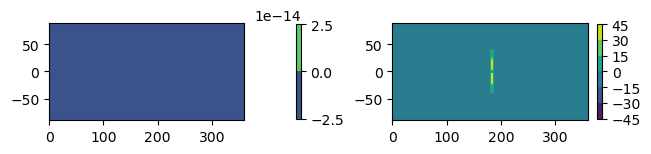

In [57]:
# Plot w field
fig, (ax1,ax2) = plt.subplots(1,2, constrained_layout=True)
plot1 = ax1.contourf(LON, LAT, w_zero)
plot2 = ax2.contourf(LON, LAT, w_nonzero)

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.colorbar(plot1,shrink=0.2)
plt.colorbar(plot2,shrink=0.2)

print(f'Maximum vertical velocity is {np.max(w_nonzero)} m/s')
print(f'Minimum vertical velocity is {np.min(w_nonzero)} m/s')

In [ ]:
# Define interplations to heights.

In [62]:
# Now, compare the final solutions.
t_idx = -1
z_val = 300

if rot == True:
    lat_crop_up = 40.
    lat_cent_down = -40.
    lat_ticks = np.linspace(-40.,40.,5)
    
    lon_crop_left = 140.
    lon_crop_right = 280.
    lon_ticks = np.linspace(140, 260, 4)
else:
    lat_crop_up = 50.
    lat_cent_down = -50.
    lat_ticks = np.linspace(-40, 40, 5)

    lon_crop_left = 160.
    lon_crop_right = 280.
    lon_ticks = np.linspace(160, 280, 7)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON_CROP, LAT_CROP = np.meshgrid(lon_crop, lat_crop)

U_zero = z_interp(nc_zero['Z3'][t_idx, :, lat_inds, lon_inds], nc_zero['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_nonzero = z_interp(nc_nonzero['Z3'][t_idx, :, lat_inds, lon_inds], nc_nonzero['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T_zero = z_interp(nc_zero['Z3'][t_idx, :, lat_inds, lon_inds], nc_zero['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_nonzero = z_interp(nc_nonzero['Z3'][t_idx, :, lat_inds, lon_inds], nc_nonzero['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

Text(0.5, 1.0, 'Nonzero w0 \n min = -10.84, max = 19.48')

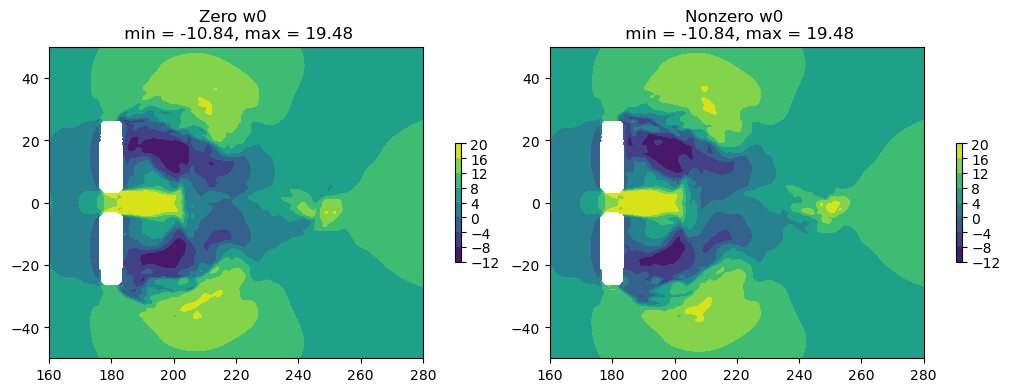

In [68]:
# Plot U field
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,6), constrained_layout=True)
plot1 = ax1.contourf(LON_CROP, LAT_CROP, U_zero)
plot2 = ax2.contourf(LON_CROP, LAT_CROP, U_nonzero)

ax1.set_aspect('equal')
ax2.set_aspect('equal')

plt.colorbar(plot1,shrink=0.2)
plt.colorbar(plot2,shrink=0.2)

ax1.set_title(f'Zero w0 \n min = {np.nanmin(U_zero):.2f}, max = {np.nanmax(U_nonzero):.2f}', size=12)
ax2.set_title(f'Nonzero w0 \n min = {np.nanmin(U_zero):.2f}, max = {np.nanmax(U_nonzero):.2f}', size=12)
